# Feature Extraction - Charité Dataset

**Objective:** Extract multi-domain features from preprocessed windowed sensor data for FoG detection, then keep a compact low-redundancy subset.

**Feature strategy:**
- extract time-domain, frequency-domain, and wavelet features
- keep **no nonlinear features**
- retain a curated subset of features that tends to be more robust and relevant for FoG: dispersion, band-energy, freezing, locomotion, and first-level wavelet energy features
- drop highly redundant families such as skew/kurtosis and wavelet variances

**Current pipeline:**
1. Load LOSO windowed splits generated in notebook 02
2. Initialize the feature extractor
3. Extract features from conservatively preprocessed windows
4. Reduce to a curated feature subset and apply light log compression on heavy-tailed energy features
5. Save per-fold feature CSVs
6. Analyze extracted features with visualizations

In [36]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm
from features import FeatureExtractor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Windowed Data

In [37]:
# Load binary LOSO splits
data_path = Path('../../outputs/datasets_csv/charite_loso_windows_binary.pkl')

with open(data_path, 'rb') as f:
    loso_splits = pickle.load(f)

print(f"✅ Loaded {len(loso_splits)} LOSO folds")
print(f"   Total train windows: {sum([len(fold['y_train']) for fold in loso_splits]):,}")
print(f"   Total test windows: {sum([len(fold['y_test']) for fold in loso_splits]):,}")

✅ Loaded 16 LOSO folds
   Total train windows: 30,405
   Total test windows: 520


## 2. Initialize Feature Extractor

Audit-aligned setting: features are extracted directly from raw windowed signals without outlier cleaning or aggressive interpolation.

In [38]:
print("✅ Preprocessed-window feature extraction enabled")
print("   Upstream cleaning: conservative SignalCleaner + detrending + robust trial normalization")
print("   Missing-value interpolation: handled upstream in notebook 02")
print("   Feature policy: curated low-redundancy subset after extraction")

✅ Preprocessed-window feature extraction enabled
   Upstream cleaning: conservative SignalCleaner + detrending + robust trial normalization
   Missing-value interpolation: handled upstream in notebook 02
   Feature policy: curated low-redundancy subset after extraction


In [39]:
# Feature extractor
SAMPLING_RATE = 200  # Hz for Charité

extractor = FeatureExtractor(
    sampling_rate=SAMPLING_RATE,
    extract_time=True,
    extract_frequency=True,
    extract_wavelet=True,
    extract_nonlinear=False  # Disabled for current experiments
)

# Channel groups for per-sensor magnitude computation
# Charité: bilateral foot IMUs with accelerometer + gyroscope channels
CHANNEL_GROUPS = {
    'acc_left_foot': [0, 1, 2],
    'gyr_left_foot': [3, 4, 5],
    'acc_right_foot': [6, 7, 8],
    'gyr_right_foot': [9, 10, 11],
}

print("✅ Feature extractor initialized")
print(f"   Sampling rate: {SAMPLING_RATE} Hz")
print(f"   Time-domain: ✅")
print(f"   Frequency-domain: ✅")
print(f"   Wavelet: ✅")
print(f"   Nonlinear: ❌")
print(f"   Channel groups: {list(CHANNEL_GROUPS.keys())}")

✅ Feature extractor initialized
   Sampling rate: 200 Hz
   Time-domain: ✅
   Frequency-domain: ✅
   Wavelet: ✅
   Nonlinear: ❌
   Channel groups: ['acc_left_foot', 'gyr_left_foot', 'acc_right_foot', 'gyr_right_foot']


In [40]:
# Expanded feature allowlist with FoG-discriminative features
FEATURE_SUFFIX_ALLOWLIST = [
    'std', 'iqr', 'rms', 'skew', 'kurt',
    'energy', 'jerk_rms', 'jerk_std',
    'coeff_variation', 'entropy',
    'mean_crossing_rate', 'zero_crossing_rate',
    'psd_total_energy', 'power_loco_band', 'power_freeze_band',
    'freezing_index', 'locomotion_band_index', 'spectral_centroid',
    'wavelet_energy_0',
]

LOG_COMPRESS_SUFFIXES = [
    'psd_total_energy', 'power_loco_band', 'power_freeze_band',
    'freezing_index', 'wavelet_energy_0', 'energy',
]

def build_curated_feature_list(columns):
    selected = [
        col for col in columns
        if any(col.endswith(suffix) for suffix in FEATURE_SUFFIX_ALLOWLIST)
    ]
    return sorted(dict.fromkeys(selected))

def postprocess_feature_frame(df):
    X = df.copy().replace([np.inf, -np.inf], np.nan)
    selected_cols = build_curated_feature_list(X.columns)
    X = X[selected_cols].copy()

    for col in X.columns:
        if any(col.endswith(suffix) for suffix in LOG_COMPRESS_SUFFIXES):
            X[col] = np.sign(X[col]) * np.log1p(np.abs(X[col]))

    return X

def add_foot_asymmetry_features(df):
    """Add foot asymmetry features: |left - right| for each matching axis.
    
    Foot asymmetry is a key indicator of FoG - during freezing,
    the bilateral coordination breaks down.
    """
    asym_features = {}
    # Map left channels to right channels (same sensor type and axis)
    left_right_pairs = [
        ('ch0_', 'ch6_'),   # acc_x left vs right
        ('ch1_', 'ch7_'),   # acc_y left vs right
        ('ch2_', 'ch8_'),   # acc_z left vs right
        ('ch3_', 'ch9_'),   # gyr_x left vs right
        ('ch4_', 'ch10_'),  # gyr_y left vs right
        ('ch5_', 'ch11_'),  # gyr_z left vs right
    ]
    
    for left_prefix, right_prefix in left_right_pairs:
        for suffix in FEATURE_SUFFIX_ALLOWLIST:
            left_col = f'{left_prefix}{suffix}'
            right_col = f'{right_prefix}{suffix}'
            if left_col in df.columns and right_col in df.columns:
                asym_col = f'asym_{left_prefix.replace("ch", "pair")}{suffix}'
                asym_features[asym_col] = np.abs(df[left_col].values - df[right_col].values)
    
    if asym_features:
        asym_df = pd.DataFrame(asym_features, index=df.index)
        return pd.concat([df, asym_df], axis=1)
    return df

print(f'Curated feature families ({len(FEATURE_SUFFIX_ALLOWLIST)}): {FEATURE_SUFFIX_ALLOWLIST}')
print(f'Log-compressed families: {LOG_COMPRESS_SUFFIXES}')
print('Foot asymmetry features: |left - right| for each axis pair')

Curated feature families (19): ['std', 'iqr', 'rms', 'skew', 'kurt', 'energy', 'jerk_rms', 'jerk_std', 'coeff_variation', 'entropy', 'mean_crossing_rate', 'zero_crossing_rate', 'psd_total_energy', 'power_loco_band', 'power_freeze_band', 'freezing_index', 'locomotion_band_index', 'spectral_centroid', 'wavelet_energy_0']
Log-compressed families: ['psd_total_energy', 'power_loco_band', 'power_freeze_band', 'freezing_index', 'wavelet_energy_0', 'energy']
Foot asymmetry features: |left - right| for each axis pair


## 3. Process All LOSO Folds

Extract features from all folds and save to CSV files.

In [41]:
# Output directory
feature_output_dir = Path('../../outputs/charite_features')
feature_output_dir.mkdir(parents=True, exist_ok=True)

# Charité windows are larger (4s × 200 Hz × 12 channels), so keep single-process extraction
N_JOBS = 1

print("Processing all LOSO folds...")
print("=" * 70)
print(f"Feature extraction workers: {N_JOBS}")

for fold in tqdm(loso_splits, desc="Processing folds"):
    test_subject = fold['test_subject']

    # 1. Extract features from preprocessed windows
    X_train_features = extractor.extract_from_windows(
        fold['X_train'], n_jobs=N_JOBS, verbose=True, channel_groups=CHANNEL_GROUPS)
    X_test_features = extractor.extract_from_windows(
        fold['X_test'], n_jobs=N_JOBS, verbose=True, channel_groups=CHANNEL_GROUPS)

    # 2. Curate features and compress heavy-tailed energy features
    X_train_features = postprocess_feature_frame(X_train_features)
    X_test_features = postprocess_feature_frame(X_test_features)

    # 3. Add foot asymmetry features (|left - right| for each axis)
    # This captures bilateral coordination breakdown during FoG
    X_train_features = add_foot_asymmetry_features(X_train_features)
    X_test_features = add_foot_asymmetry_features(X_test_features)

    # 4. Save to CSV
    fold_dir = feature_output_dir / f'fold_subj_{test_subject}'
    fold_dir.mkdir(parents=True, exist_ok=True)

    X_train_features.to_csv(fold_dir / 'X_train_features.csv', index=False)
    pd.Series(fold['y_train'], name='label').to_csv(fold_dir / 'y_train.csv', index=False)
    pd.Series(fold['subjects_train'], name='subject').to_csv(fold_dir / 'subjects_train.csv', index=False)
    X_test_features.to_csv(fold_dir / 'X_test_features.csv', index=False)
    pd.Series(fold['y_test'], name='label').to_csv(fold_dir / 'y_test.csv', index=False)

n_asym = len([c for c in X_train_features.columns if c.startswith('asym_')])
print("\n" + "=" * 70)
print(f"Feature extraction complete for {len(loso_splits)} folds")
print(f"Output directory: {feature_output_dir}")
print(f"Curated features: {X_train_features.shape[1]} (including {n_asym} asymmetry features)")
print("=" * 70)

Processing all LOSO folds...
Feature extraction workers: 1


Processing folds: 100%|██████████| 16/16 [10:03<00:00, 37.74s/it]


Feature extraction complete for 16 folds
Output directory: ..\..\outputs\charite_features
Curated features: 302 (including 78 asymmetry features)


## 4. Load Sample Features for Analysis

Load features from the first fold for visualization and analysis.

In [42]:
# Load first fold for analysis (dynamically find first available fold)
available_folds = sorted([d for d in feature_output_dir.iterdir() if d.is_dir()])
if not available_folds:
    raise FileNotFoundError(f"No fold directories found in {feature_output_dir}")
sample_fold_dir = available_folds[0]

X_train_features = pd.read_csv(sample_fold_dir / 'X_train_features.csv')
y_train = pd.read_csv(sample_fold_dir / 'y_train.csv').squeeze()
X_test_features = pd.read_csv(sample_fold_dir / 'X_test_features.csv')
y_test = pd.read_csv(sample_fold_dir / 'y_test.csv').squeeze()

print(f"📊 Loaded features from: {sample_fold_dir.name}")
print(f"   Train: {X_train_features.shape}")
print(f"   Test: {X_test_features.shape}")
print(f"   Features: {X_train_features.shape[1]}")
print(f"\n📋 First 10 features:")
for i, col in enumerate(X_train_features.columns[:10], 1):
    print(f"   {i}. {col}")

📊 Loaded features from: fold_subj_S01
   Train: (1968, 302)
   Test: (15, 302)
   Features: 302

📋 First 10 features:
   1. acc_left_foot_mag_freezing_index
   2. acc_left_foot_mag_iqr
   3. acc_left_foot_mag_kurt
   4. acc_left_foot_mag_locomotion_band_index
   5. acc_left_foot_mag_power_freeze_band
   6. acc_left_foot_mag_power_loco_band
   7. acc_left_foot_mag_psd_total_energy
   8. acc_left_foot_mag_rms
   9. acc_left_foot_mag_skew
   10. acc_left_foot_mag_spectral_centroid


## 5. Feature Statistics

In [43]:
# Statistical summary
print("📈 Feature Statistics (Train Set):")
print(X_train_features.describe())

📈 Feature Statistics (Train Set):
       acc_left_foot_mag_freezing_index  acc_left_foot_mag_iqr  \
count                       1968.000000            1968.000000   
mean                           0.466457               2.450255   
std                            0.325094               1.669847   
min                            0.017836               0.068331   
25%                            0.249628               1.095017   
50%                            0.373098               2.192222   
75%                            0.571853               3.498396   
max                            2.543668              10.314240   

       acc_left_foot_mag_kurt  acc_left_foot_mag_locomotion_band_index  \
count             1968.000000                              1968.000000   
mean                 2.946355                                 0.366213   
std                  5.331577                                 0.123600   
min                 -1.479858                                 0.038571   
2

## 6. Feature Distributions: FoG vs No FoG

Compare key features between FoG and No FoG windows.

📊 Class Distribution:
   No FoG: 290 windows (14.7%)
   FoG: 1,678 windows (85.3%)


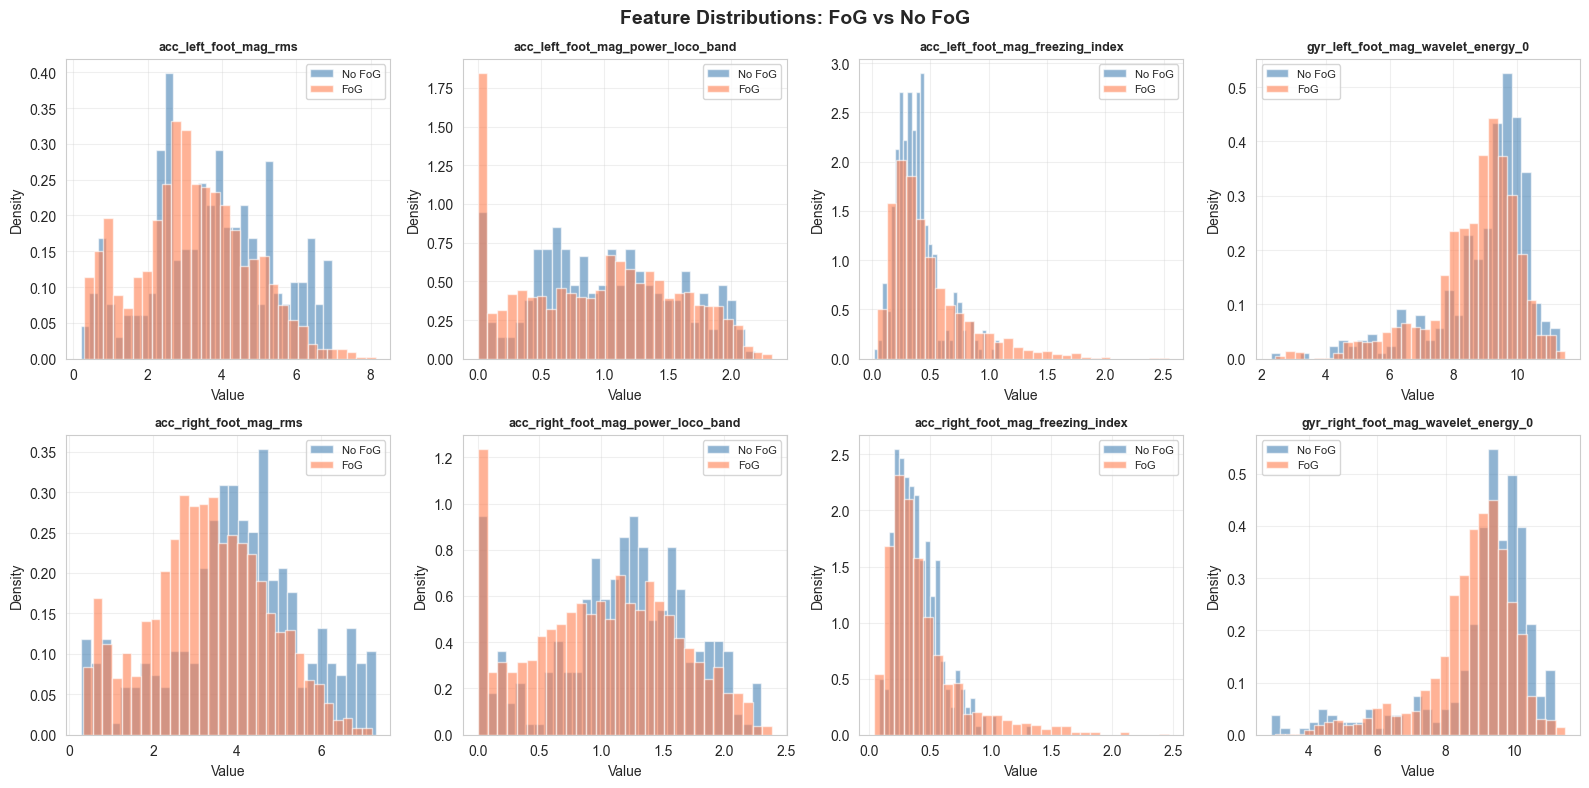

In [44]:
# Separate by class
features_no_fog = X_train_features[y_train == 0].replace([np.inf, -np.inf], np.nan)
features_fog    = X_train_features[y_train == 1].replace([np.inf, -np.inf], np.nan)

print(f"📊 Class Distribution:")
print(f"   No FoG: {len(features_no_fog):,} windows ({len(features_no_fog)/len(X_train_features)*100:.1f}%)")
print(f"   FoG: {len(features_fog):,} windows ({len(features_fog)/len(X_train_features)*100:.1f}%)")

# Select representative curated features (magnitude + robust spectral features)
feature_subset = [
    'acc_left_foot_mag_rms', 'acc_left_foot_mag_power_loco_band',
    'acc_left_foot_mag_freezing_index', 'gyr_left_foot_mag_wavelet_energy_0',
    'acc_right_foot_mag_rms', 'acc_right_foot_mag_power_loco_band',
    'acc_right_foot_mag_freezing_index', 'gyr_right_foot_mag_wavelet_energy_0',
]

feature_subset = [f for f in feature_subset if f in X_train_features.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feat in enumerate(feature_subset[:8]):
    axes[i].hist(features_no_fog[feat].dropna(), bins=30, alpha=0.6,
                 label='No FoG', color='steelblue', density=True)
    axes[i].hist(features_fog[feat].dropna(), bins=30, alpha=0.6,
                 label='FoG', color='coral', density=True)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

for i in range(len(feature_subset), 8):
    axes[i].axis('off')

plt.suptitle('Feature Distributions: FoG vs No FoG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance by Variance

Identify features with highest variance (potentially most discriminative).

📊 Top 15 Features by Variance:
 1. ch11_kurt                                  41.32
 2. ch7_kurt                                   38.56
 3. acc_right_foot_mag_kurt                    34.09
 4. gyr_left_foot_mag_kurt                     33.61
 5. ch1_kurt                                   33.32
 6. asym_pair5_kurt                            32.51
 7. ch5_kurt                                   32.50
 8. asym_pair1_kurt                            31.79
 9. ch4_kurt                                   31.47
10. acc_left_foot_mag_kurt                     28.43
11. ch10_kurt                                  28.18
12. ch6_kurt                                   27.89
13. asym_pair0_kurt                            24.34
14. asym_pair4_kurt                            24.04
15. ch2_kurt                                   23.79


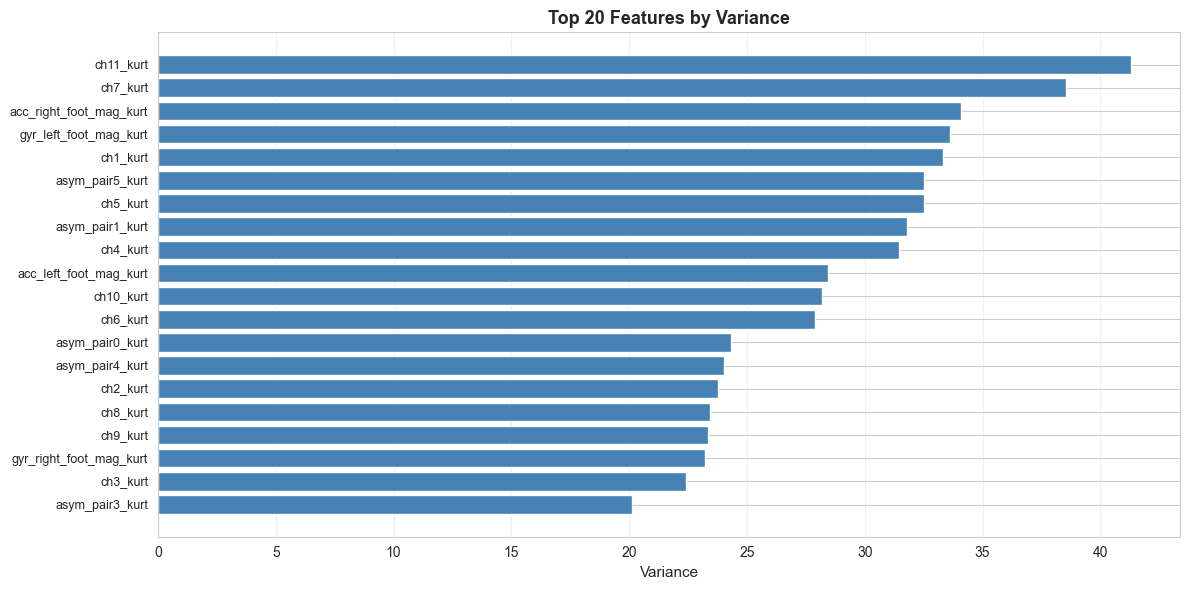

In [45]:
# Calculate variance for each feature (replace inf with NaN before var to avoid inf results)
feature_variance = (
    X_train_features
    .replace([np.inf, -np.inf], np.nan)
    .var()
    .sort_values(ascending=False)
)

print("📊 Top 15 Features by Variance:")
print("=" * 60)
for i, (feat, var) in enumerate(feature_variance.head(15).items(), 1):
    print(f"{i:2d}. {feat:35s} {var:12.2f}")

# Visualize top features by variance
fig, ax = plt.subplots(figsize=(12, 6))
top_features = feature_variance.dropna().head(20)
ax.barh(range(len(top_features)), top_features.values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.set_xlabel('Variance', fontsize=11)
ax.set_title('Top 20 Features by Variance', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Feature Correlation Analysis

Identify highly correlated features (potential redundancy).

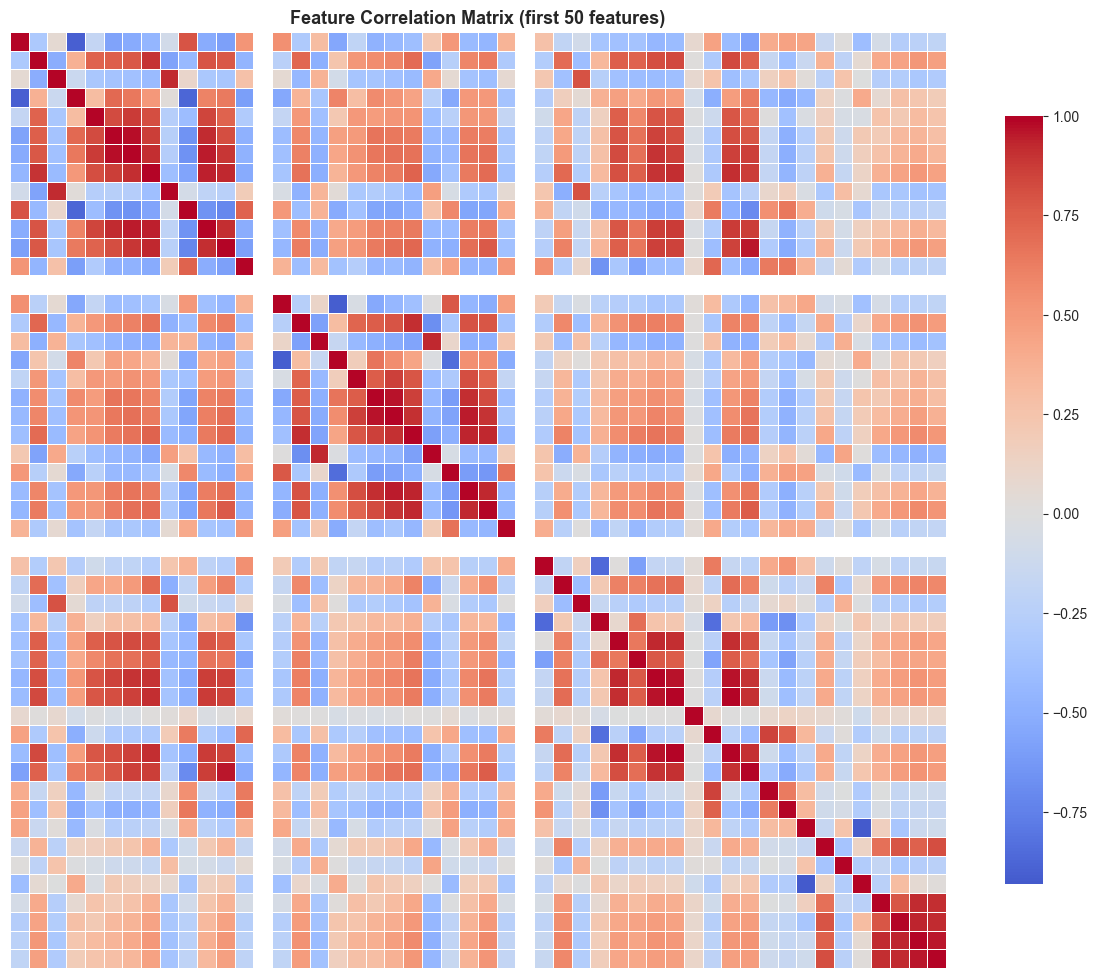


⚠️  Highly correlated pairs (|r| > 0.9): 39

Top 10 correlations:
  ch0_rms                        <-> ch0_std                       :  1.000
  acc_left_foot_mag_power_loco_band <-> acc_left_foot_mag_psd_total_energy:  0.973
  ch0_psd_total_energy           <-> ch0_std                       :  0.969
  ch0_psd_total_energy           <-> ch0_rms                       :  0.968
  acc_right_foot_mag_power_loco_band <-> acc_right_foot_mag_psd_total_energy:  0.964
  ch10_psd_total_energy          <-> ch10_rms                      :  0.958
  acc_left_foot_mag_wavelet_energy_0 <-> ch0_wavelet_energy_0          :  0.955
  acc_left_foot_mag_psd_total_energy <-> acc_left_foot_mag_std         :  0.951
  acc_right_foot_mag_psd_total_energy <-> acc_right_foot_mag_std        :  0.950
  acc_left_foot_mag_rms          <-> acc_left_foot_mag_std         :  0.940


In [46]:
# Compute correlation matrix (replace inf with NaN before corr to avoid propagation)
n_features_viz = min(50, X_train_features.shape[1])
features_sample = (
    X_train_features
    .replace([np.inf, -np.inf], np.nan)
    .iloc[:, :n_features_viz]
)
corr_matrix = features_sample.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
           xticklabels=False, yticklabels=False)
ax.set_title(f'Feature Correlation Matrix (first {n_features_viz} features)', 
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if np.isfinite(val) and abs(val) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                val
            ))

print(f"\n⚠️  Highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nTop 10 correlations:")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1:30s} <-> {feat2:30s}: {corr:6.3f}")

## 9. Class Separability Analysis

Measure how well features separate FoG from No FoG using effect size (Cohen's d).

📊 Top 15 Features by Effect Size (Cohen's d):
   Higher effect size = better class separability
   d > 0.8: Large effect
   d > 0.5: Medium effect
   d > 0.2: Small effect
 1. ch0_locomotion_band_index           d=1.217  (Large)
 2. ch1_zero_crossing_rate              d=1.204  (Large)
 3. ch7_zero_crossing_rate              d=1.178  (Large)
 4. ch0_zero_crossing_rate              d=1.151  (Large)
 5. ch6_zero_crossing_rate              d=1.094  (Large)
 6. ch7_locomotion_band_index           d=1.055  (Large)
 7. ch9_locomotion_band_index           d=0.996  (Large)
 8. ch0_freezing_index                  d=0.992  (Large)
 9. ch3_locomotion_band_index           d=0.952  (Large)
10. ch0_spectral_centroid               d=0.940  (Large)
11. ch8_zero_crossing_rate              d=0.937  (Large)
12. ch2_zero_crossing_rate              d=0.935  (Large)
13. ch1_locomotion_band_index           d=0.935  (Large)
14. ch7_freezing_index                  d=0.934  (Large)
15. ch6_locomotion_band_index 

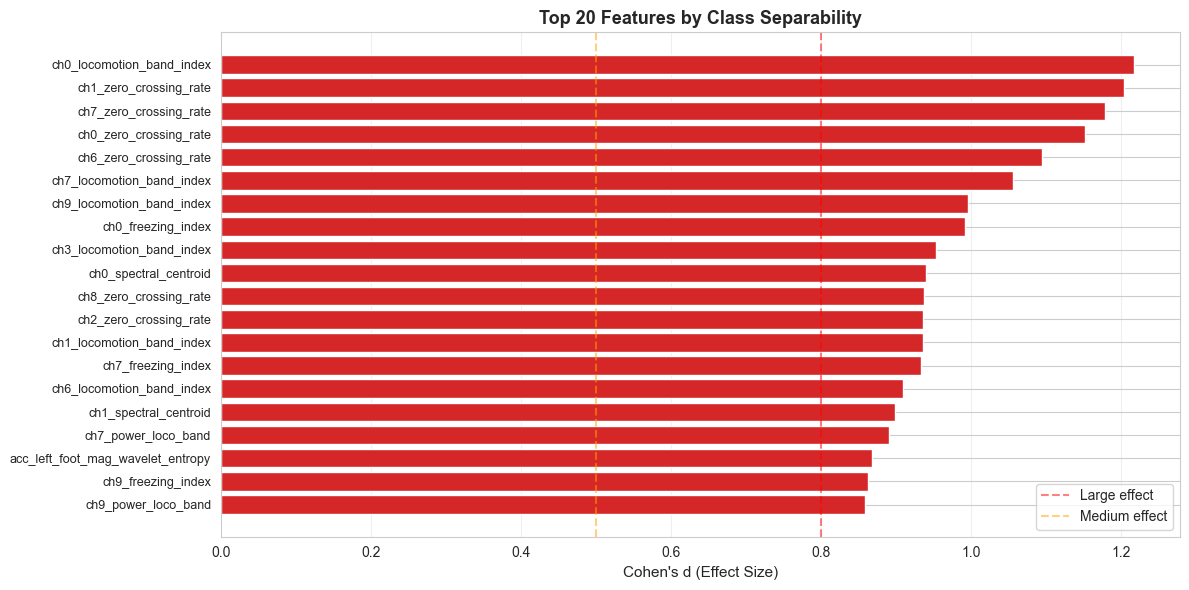

In [47]:
# Calculate Cohen's d for each feature
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    mean1, mean2 = group1.mean(), group2.mean()
    std1, std2 = group1.std(), group2.std()
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))
    return abs((mean1 - mean2) / pooled_std) if pooled_std > 0 else 0

effect_sizes = {}
for col in X_train_features.columns:
    d = cohens_d(features_no_fog[col].dropna(), features_fog[col].dropna())
    effect_sizes[col] = d

effect_sizes = pd.Series(effect_sizes).sort_values(ascending=False)

print("📊 Top 15 Features by Effect Size (Cohen's d):")
print("=" * 70)
print("   Higher effect size = better class separability")
print("   d > 0.8: Large effect")
print("   d > 0.5: Medium effect")
print("   d > 0.2: Small effect")
print("=" * 70)
for i, (feat, d) in enumerate(effect_sizes.head(15).items(), 1):
    magnitude = "Large" if d > 0.8 else "Medium" if d > 0.5 else "Small" if d > 0.2 else "Negligible"
    print(f"{i:2d}. {feat:35s} d={d:5.3f}  ({magnitude})")

# Visualize top features by effect size
fig, ax = plt.subplots(figsize=(12, 6))
top_effects = effect_sizes.head(20)
colors = ['#d62728' if d > 0.8 else '#ff7f0e' if d > 0.5 else '#2ca02c' for d in top_effects.values]
ax.barh(range(len(top_effects)), top_effects.values, color=colors)
ax.set_yticks(range(len(top_effects)))
ax.set_yticklabels(top_effects.index, fontsize=9)
ax.set_xlabel("Cohen's d (Effect Size)", fontsize=11)
ax.set_title('Top 20 Features by Class Separability', fontsize=13, fontweight='bold')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large effect')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium effect')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Summary

In [48]:
# Summary statistics
total_train = sum([len(fold['y_train']) for fold in loso_splits])
total_test = sum([len(fold['y_test']) for fold in loso_splits])

print("=" * 70)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 70)

print(f"\n📊 Feature Configuration:")
print(f"   Time-domain: ✅ Enabled")
print(f"   Frequency-domain: ✅ Enabled")
print(f"   Wavelet: ✅ Enabled")
print(f"   Nonlinear: ❌ Disabled")
print(f"   Curated feature families: {FEATURE_SUFFIX_ALLOWLIST}")

print(f"\n📈 Processing Statistics:")
print(f"   LOSO folds: {len(loso_splits)}")
print(f"   Total train windows: {total_train:,}")
print(f"   Total test windows: {total_test:,}")
print(f"   Features per window after curation: {X_train_features.shape[1]}")

print(f"\n🧱 Window / Signal Handling:")
print(f"   Source: conservatively preprocessed windows from notebook 02")
print(f"   Trial detrending: enabled upstream")
print(f"   Robust trial normalization: enabled upstream")
print(f"   Feature extraction workers: {N_JOBS}")

print(f"\n💾 Output:")
print(f"   Directory: {feature_output_dir}")
print(f"   Files per fold: X_train_features.csv, y_train.csv, subjects_train.csv, X_test_features.csv, y_test.csv")

print(f"\n🎯 Key Insights:")
print(f"   Top feature (variance): {feature_variance.index[0]}")
print(f"   Top feature (effect size): {effect_sizes.index[0]} (d={effect_sizes.iloc[0]:.3f})")
print(f"   Highly correlated pairs: {len(high_corr_pairs)}")

print("\n" + "=" * 70)
print("✅ Curated feature dataset ready for training!")
print("📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb")
print("=" * 70)

FEATURE EXTRACTION SUMMARY

📊 Feature Configuration:
   Time-domain: ✅ Enabled
   Frequency-domain: ✅ Enabled
   Wavelet: ✅ Enabled
   Nonlinear: ❌ Disabled
   Curated feature families: ['std', 'iqr', 'rms', 'skew', 'kurt', 'energy', 'jerk_rms', 'jerk_std', 'coeff_variation', 'entropy', 'mean_crossing_rate', 'zero_crossing_rate', 'psd_total_energy', 'power_loco_band', 'power_freeze_band', 'freezing_index', 'locomotion_band_index', 'spectral_centroid', 'wavelet_energy_0']

📈 Processing Statistics:
   LOSO folds: 16
   Total train windows: 30,405
   Total test windows: 520
   Features per window after curation: 302

🧱 Window / Signal Handling:
   Source: conservatively preprocessed windows from notebook 02
   Trial detrending: enabled upstream
   Robust trial normalization: enabled upstream
   Feature extraction workers: 1

💾 Output:
   Directory: ..\..\outputs\charite_features
   Files per fold: X_train_features.csv, y_train.csv, subjects_train.csv, X_test_features.csv, y_test.csv

🎯 Ke

## 11. Raw Model Training for Preprocessing Experiments

This section adds a **fast LOSO baseline** to evaluate preprocessing choices directly from the extracted feature CSVs.

**Design goals:**
- no hyperparameter tuning
- no feature selection
- fixed, simple models
- configurable preprocessing steps so you can compare variants quickly
- optional class balancing with `SMOTE` to test whether `F1` improves or degrades
- configurable imputation, including `KNNImputer`, to test whether feature-space missing-value handling helps

Edit the configuration cell below to experiment with imputation, scaling, and class balancing.

In [49]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix
)
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

PREPROCESSING_EXPERIMENT_NAME = 'baseline_curated_features_robust'
PREPROCESSING_CONFIG = {
    'replace_inf_with_nan': True,
    'imputer_strategy': 'median',  # options: knn, median, mean, most_frequent, none
    'knn_imputer_neighbors': 5,
    'scaler': 'robust',            # options: standard, robust, none
    'resampler': 'none',           # options: none, random_oversampler, smote, adasyn
    'resampler_k_neighbors': 5,
}

RAW_BASELINE_MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=300,
        early_stopping=True,
        random_state=42
    ),
}

def clean_raw_features(df, replace_inf_with_nan=True):
    X = df.copy()
    if replace_inf_with_nan:
        X = X.replace([np.inf, -np.inf], np.nan)
    return X

def build_raw_baseline_pipeline(model, config, y_train=None):
    steps = []

    if config['imputer_strategy'] == 'knn':
        steps.append(('imputer', KNNImputer(n_neighbors=config['knn_imputer_neighbors'])))
    elif config['imputer_strategy'] != 'none':
        steps.append(('imputer', SimpleImputer(strategy=config['imputer_strategy'])))

    if config['scaler'] == 'standard':
        steps.append(('scaler', StandardScaler()))
    elif config['scaler'] == 'robust':
        steps.append(('scaler', RobustScaler()))

    if config['resampler'] == 'random_oversampler':
        steps.append(('ros', RandomOverSampler(random_state=42)))
    elif config['resampler'] in ('smote', 'adasyn'):
        if y_train is None:
            raise ValueError('y_train is required when using SMOTE or ADASYN')
        minority_count = int(pd.Series(y_train).value_counts().min())
        if minority_count >= 2:
            k_neighbors = min(config['resampler_k_neighbors'], minority_count - 1)
            if config['resampler'] == 'smote':
                steps.append(('smote', SMOTE(random_state=42, k_neighbors=k_neighbors)))
            else:
                steps.append(('adasyn', ADASYN(random_state=42, n_neighbors=k_neighbors)))
        else:
            print('  ⚠️ Resampler skipped: not enough minority samples in training fold.')

    steps.append(('classifier', model))
    return ImbPipeline(steps)

print('Raw baseline training config:')
print(f"  Experiment name: {PREPROCESSING_EXPERIMENT_NAME}")
for key, value in PREPROCESSING_CONFIG.items():
    print(f"  - {key}: {value}")
print('Models:', ', '.join(RAW_BASELINE_MODELS.keys()))

Raw baseline training config:
  Experiment name: baseline_curated_features_robust
  - replace_inf_with_nan: True
  - imputer_strategy: median
  - knn_imputer_neighbors: 5
  - scaler: robust
  - resampler: none
  - resampler_k_neighbors: 5
Models: Logistic Regression, Random Forest, MLP


In [50]:
from pathlib import Path
import json

fold_dirs = sorted([p for p in feature_output_dir.glob('fold_subj_*') if p.is_dir()])
results_output_dir = feature_output_dir.parent / 'charite_results'
results_output_dir.mkdir(parents=True, exist_ok=True)

print(f'Found {len(fold_dirs)} fold directories in {feature_output_dir}')

raw_baseline_rows = []
raw_baseline_predictions = []

for fold_dir in fold_dirs:
    subject_id = fold_dir.name.replace('fold_subj_', '')

    X_train = pd.read_csv(fold_dir / 'X_train_features.csv')
    X_test = pd.read_csv(fold_dir / 'X_test_features.csv')
    y_train = pd.read_csv(fold_dir / 'y_train.csv').squeeze('columns')
    y_test = pd.read_csv(fold_dir / 'y_test.csv').squeeze('columns')

    X_train = clean_raw_features(
        X_train,
        replace_inf_with_nan=PREPROCESSING_CONFIG['replace_inf_with_nan']
    )
    X_test = clean_raw_features(
        X_test,
        replace_inf_with_nan=PREPROCESSING_CONFIG['replace_inf_with_nan']
    )

    print(f'\n=== Fold {subject_id} ===')
    print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
    print(f'Train class distribution: {dict(pd.Series(y_train).value_counts().sort_index())}')
    print(f'Test class distribution: {dict(pd.Series(y_test).value_counts().sort_index())}')

    for model_name, model in RAW_BASELINE_MODELS.items():
        pipeline = build_raw_baseline_pipeline(model, PREPROCESSING_CONFIG, y_train=y_train)
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

        metrics_row = {
            'subject_id': subject_id,
            'model': model_name,
            'n_train': len(X_train),
            'n_test': len(X_test),
            'n_features': X_train.shape[1],
            'accuracy': accuracy_score(y_test, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'tp': int(tp),
            'resampler': PREPROCESSING_CONFIG['resampler'],
        }
        raw_baseline_rows.append(metrics_row)

        fold_predictions = pd.DataFrame({
            'subject_id': subject_id,
            'model': model_name,
            'y_true': y_test.to_numpy(),
            'y_pred': y_pred,
            'resampler': PREPROCESSING_CONFIG['resampler'],
        })
        raw_baseline_predictions.append(fold_predictions)

raw_baseline_results = pd.DataFrame(raw_baseline_rows)
raw_baseline_summary = (
    raw_baseline_results
    .groupby('model')[['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1']]
    .agg(['mean', 'std'])
    .round(4)
    .sort_values(('f1', 'mean'), ascending=False)
)

predictions_df = pd.concat(raw_baseline_predictions, ignore_index=True)

results_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_results.csv'
summary_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_summary.csv'
predictions_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_predictions.csv'
config_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_config.json'

raw_baseline_results.to_csv(results_path, index=False)
raw_baseline_summary.to_csv(summary_path)
predictions_df.to_csv(predictions_path, index=False)

config_payload = {
    'experiment_name': PREPROCESSING_EXPERIMENT_NAME,
    'preprocessing_config': PREPROCESSING_CONFIG,
    'models': list(RAW_BASELINE_MODELS.keys()),
    'n_folds': len(fold_dirs),
}
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config_payload, f, indent=2)

display(raw_baseline_results.head())
display(raw_baseline_summary)

print(f'\nSaved fold-level results to: {results_path}')
print(f'Saved summary to: {summary_path}')
print(f'Saved predictions to: {predictions_path}')
print(f'Saved config to: {config_path}')

Found 16 fold directories in ..\..\outputs\charite_features

=== Fold S01 ===
Train shape: (1968, 302) | Test shape: (15, 302)
Train class distribution: {0: 290, 1: 1678}
Test class distribution: {0: 9, 1: 6}

=== Fold S02 ===
Train shape: (1739, 302) | Test shape: (73, 302)
Train class distribution: {0: 305, 1: 1434}
Test class distribution: {0: 5, 1: 68}

=== Fold S03 ===
Train shape: (1446, 302) | Test shape: (146, 302)
Train class distribution: {0: 297, 1: 1149}
Test class distribution: {0: 5, 1: 141}

=== Fold S04 ===
Train shape: (1984, 302) | Test shape: (12, 302)
Train class distribution: {0: 299, 1: 1685}
Test class distribution: {0: 8, 1: 4}

=== Fold S05 ===
Train shape: (1966, 302) | Test shape: (16, 302)
Train class distribution: {0: 291, 1: 1675}
Test class distribution: {0: 9, 1: 7}

=== Fold S06 ===
Train shape: (1940, 302) | Test shape: (23, 302)
Train class distribution: {0: 306, 1: 1634}
Test class distribution: {0: 5, 1: 18}

=== Fold S07 ===
Train shape: (1969, 302

,subject_id,model,n_train,n_test,n_features,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp,resampler
0,S01,Logistic Regression,1968,15,302,0.800000,0.833333,0.666667,1.000000,0.800000,6,3,0,6,none
1,S01,Random Forest,1968,15,302,0.600000,0.666667,0.500000,1.000000,0.666667,3,6,0,6,none
2,S01,MLP,1968,15,302,0.666667,0.722222,0.545455,1.000000,0.705882,4,5,0,6,none
3,S02,Logistic Regression,1739,73,302,0.753425,0.497059,0.931034,0.794118,0.857143,1,4,14,54,none
4,S02,Random Forest,1739,73,302,0.931507,0.500000,0.931507,1.000000,0.964539,0,5,0,68,none


accuracy         balanced_accuracy         precision  \
                        mean     std              mean     std      mean   
model                                                                      
MLP                   0.8507  0.0979            0.7445  0.1382    0.8682   
Logistic Regression   0.7993  0.0870            0.7296  0.1488    0.8737   
Random Forest         0.7643  0.1424            0.5979  0.0803    0.7509   

                             recall              f1          
                        std    mean     std    mean     std  
model                                                        
MLP                  0.1273  0.9243  0.1153  0.8857  0.0929  
Logistic Regression  0.1223  0.8285  0.1597  0.8347  0.0931  
Random Forest        0.1703  0.9701  0.0704  0.8343  0.1234


Saved fold-level results to: ..\..\outputs\charite_results\baseline_curated_features_robust_raw_model_results.csv
Saved summary to: ..\..\outputs\charite_results\baseline_curated_features_robust_raw_model_summary.csv
Saved predictions to: ..\..\outputs\charite_results\baseline_curated_features_robust_raw_model_predictions.csv
Saved config to: ..\..\outputs\charite_results\baseline_curated_features_robust_raw_model_config.json


## 12. Lightweight LOSO Training for Quick Validation

This section adds a **light Notebook 04-style training pass** directly inside notebook 03 so it can be tested quickly after feature extraction.

**What it includes:**
- train-only preprocessing in each LOSO fold
- per-subject robust normalization in feature space
- removal of constant features using the training split only
- lightweight `SelectKBest` feature selection
- median imputation + robust scaling + random oversampling
- threshold tuning from out-of-fold training predictions with `GroupKFold`

**Design goal:**
- faster than the full notebook 04 pipeline
- subject-aware and reasonably leakage-safe
- good enough for rapid iteration before running the heavier experiments

In [51]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve

LIGHT_TRAINING_EXPERIMENT_NAME = 'lightweight_loso_curated_thresholded'
LIGHT_TRAINING_CONFIG = {
    'replace_inf_with_nan': True,
    'k_best': 48,
    'scaler': 'robust',
    'resampler': 'random_oversampler',
    'max_inner_splits': 4,
    'threshold_clip': (0.35, 0.65),
}

LIGHT_TRAINING_MODELS = {
    'Logistic Regression': LogisticRegression(
        C=1.0,
        solver='liblinear',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=250,
        max_depth=12,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
}

def per_subject_robust_normalize(X, groups):
    X_norm = X.copy()
    groups = pd.Series(groups).astype(str).reset_index(drop=True)
    X_norm = X_norm.reset_index(drop=True)

    for subject in groups.unique():
        mask = groups == subject
        block = X_norm.loc[mask].copy()
        median = block.median(axis=0)
        iqr = block.quantile(0.75, axis=0) - block.quantile(0.25, axis=0)
        iqr = iqr.replace(0, 1.0).fillna(1.0)
        X_norm.loc[mask] = (block - median) / iqr

    return X_norm

def prepare_fold_feature_matrices(X_train, X_test, subjects_train, subject_id, replace_inf_with_nan=True):
    X_train = clean_raw_features(X_train, replace_inf_with_nan=replace_inf_with_nan)
    X_test = clean_raw_features(X_test, replace_inf_with_nan=replace_inf_with_nan)

    train_groups = pd.Series(subjects_train).astype(str).reset_index(drop=True)
    test_groups = pd.Series([str(subject_id)] * len(X_test))

    X_train = per_subject_robust_normalize(X_train, train_groups)
    X_test = per_subject_robust_normalize(X_test, test_groups)

    non_constant_cols = X_train.columns[X_train.nunique(dropna=False) > 1].tolist()
    if not non_constant_cols:
        non_constant_cols = X_train.columns.tolist()

    return (
        X_train[non_constant_cols].copy(),
        X_test[non_constant_cols].copy(),
        train_groups,
        non_constant_cols,
    )

def build_light_training_pipeline(model, config, n_features):
    k_best = max(1, min(config['k_best'], n_features))
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(score_func=f_classif, k=k_best)),
    ]

    if config['scaler'] == 'robust':
        steps.append(('scaler', RobustScaler()))

    if config['resampler'] == 'random_oversampler':
        steps.append(('ros', RandomOverSampler(random_state=42)))

    steps.append(('classifier', clone(model)))
    return ImbPipeline(steps)

def tune_binary_threshold(pipeline, X_train, y_train, groups, n_splits, threshold_clip=(0.35, 0.65)):
    if n_splits < 2 or pd.Series(y_train).nunique() < 2:
        return 0.5

    y_score_oof = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        groups=groups,
        cv=GroupKFold(n_splits=n_splits),
        method='predict_proba',
        n_jobs=1,
    )[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_train, y_score_oof)
    if len(thresholds) == 0:
        return 0.5

    f1_values = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
    best_idx = int(np.argmax(f1_values))
    low, high = threshold_clip
    return float(np.clip(thresholds[best_idx], low, high))

print('Lightweight LOSO training config:')
print(f"  Experiment name: {LIGHT_TRAINING_EXPERIMENT_NAME}")
for key, value in LIGHT_TRAINING_CONFIG.items():
    print(f"  - {key}: {value}")
print('Models:', ', '.join(LIGHT_TRAINING_MODELS.keys()))

Lightweight LOSO training config:
  Experiment name: lightweight_loso_curated_thresholded
  - replace_inf_with_nan: True
  - k_best: 48
  - scaler: robust
  - resampler: random_oversampler
  - max_inner_splits: 4
  - threshold_clip: (0.35, 0.65)
Models: Logistic Regression, Random Forest


In [52]:
light_rows = []
light_prediction_frames = []

for fold_dir in fold_dirs:
    subject_id = fold_dir.name.replace('fold_subj_', '')

    X_train = pd.read_csv(fold_dir / 'X_train_features.csv')
    X_test = pd.read_csv(fold_dir / 'X_test_features.csv')
    y_train = pd.read_csv(fold_dir / 'y_train.csv').squeeze('columns')
    y_test = pd.read_csv(fold_dir / 'y_test.csv').squeeze('columns')
    subjects_train = pd.read_csv(fold_dir / 'subjects_train.csv').squeeze('columns')

    X_train_prep, X_test_prep, train_groups, kept_cols = prepare_fold_feature_matrices(
        X_train,
        X_test,
        subjects_train,
        subject_id,
        replace_inf_with_nan=LIGHT_TRAINING_CONFIG['replace_inf_with_nan'],
    )

    unique_groups = train_groups.nunique()
    inner_splits = min(LIGHT_TRAINING_CONFIG['max_inner_splits'], unique_groups)

    print(f"\n=== Lightweight LOSO Fold {subject_id} ===")
    print(f"Train shape after prep: {X_train_prep.shape} | Test shape after prep: {X_test_prep.shape}")
    print(f"Unique train subjects for threshold tuning: {unique_groups}")

    if pd.Series(y_train).nunique() < 2:
        print('  ⚠️ Skipping fold: training split is monoclase.')
        continue

    for model_name, base_model in LIGHT_TRAINING_MODELS.items():
        print(f"  -> Training {model_name} ...")

        pipeline = build_light_training_pipeline(
            base_model,
            LIGHT_TRAINING_CONFIG,
            n_features=X_train_prep.shape[1],
        )

        threshold = tune_binary_threshold(
            pipeline,
            X_train_prep,
            y_train,
            train_groups,
            n_splits=inner_splits,
            threshold_clip=LIGHT_TRAINING_CONFIG['threshold_clip'],
        )

        pipeline.fit(X_train_prep, y_train)
        y_score = pipeline.predict_proba(X_test_prep)[:, 1]
        y_pred = (y_score >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
        selected_count = int(pipeline.named_steps['selector'].get_support().sum())

        light_rows.append({
            'subject_id': subject_id,
            'model': model_name,
            'threshold': threshold,
            'accuracy': accuracy_score(y_test, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'tp': int(tp),
            'n_train': len(X_train_prep),
            'n_test': len(X_test_prep),
            'n_features_before_select': X_train_prep.shape[1],
            'n_features_selected': selected_count,
            'inner_cv_splits': inner_splits,
        })

        light_prediction_frames.append(pd.DataFrame({
            'subject_id': subject_id,
            'model': model_name,
            'y_true': y_test.to_numpy(),
            'y_score': y_score,
            'y_pred': y_pred,
            'threshold': threshold,
        }))

light_results_df = pd.DataFrame(light_rows)
light_predictions_df = pd.concat(light_prediction_frames, ignore_index=True) if light_prediction_frames else pd.DataFrame()

light_summary_df = (
    light_results_df
    .groupby('model')[['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'threshold', 'n_features_selected']]
    .agg(['mean', 'std'])
    .round(4)
    .sort_values(('f1', 'mean'), ascending=False)
    if not light_results_df.empty else pd.DataFrame()
)

light_results_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_results.csv'
light_summary_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_summary.csv'
light_predictions_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_predictions.csv'
light_config_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_config.json'

light_results_df.to_csv(light_results_path, index=False)
light_summary_df.to_csv(light_summary_path)
light_predictions_df.to_csv(light_predictions_path, index=False)

with open(light_config_path, 'w', encoding='utf-8') as f:
    json.dump({
        'experiment_name': LIGHT_TRAINING_EXPERIMENT_NAME,
        'config': LIGHT_TRAINING_CONFIG,
        'models': list(LIGHT_TRAINING_MODELS.keys()),
        'n_folds_evaluated': int(light_results_df['subject_id'].nunique()) if not light_results_df.empty else 0,
    }, f, indent=2)

display(light_results_df.head())
display(light_summary_df)

print(f'\nSaved lightweight fold-level results to: {light_results_path}')
print(f'Saved lightweight summary to: {light_summary_path}')
print(f'Saved lightweight predictions to: {light_predictions_path}')
print(f'Saved lightweight config to: {light_config_path}')


=== Lightweight LOSO Fold S01 ===
Train shape after prep: (1968, 298) | Test shape after prep: (15, 298)
Unique train subjects for threshold tuning: 15
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S02 ===
Train shape after prep: (1739, 298) | Test shape after prep: (73, 298)
Unique train subjects for threshold tuning: 15
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S03 ===
Train shape after prep: (1446, 298) | Test shape after prep: (146, 298)
Unique train subjects for threshold tuning: 15
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S04 ===
Train shape after prep: (1984, 298) | Test shape after prep: (12, 298)
Unique train subjects for threshold tuning: 15
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S05 ===
Train shape after prep: (1966, 298) | Test shape after prep: (16, 298)
U

,subject_id,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp,n_train,n_test,n_features_before_select,n_features_selected,inner_cv_splits
0,S01,Logistic Regression,0.35,0.600000,0.638889,0.500000,0.833333,0.625000,4,5,1,5,1968,15,298,48,4
1,S01,Random Forest,0.35,0.400000,0.500000,0.400000,1.000000,0.571429,0,9,0,6,1968,15,298,48,4
2,S02,Logistic Regression,0.35,0.931507,0.592647,0.943662,0.985294,0.964029,1,4,1,67,1739,73,298,48,4
3,S02,Random Forest,0.35,0.931507,0.500000,0.931507,1.000000,0.964539,0,5,0,68,1739,73,298,48,4
4,S03,Logistic Regression,0.35,0.767123,0.493617,0.965217,0.787234,0.867188,1,4,30,111,1446,146,298,48,4


accuracy         balanced_accuracy         precision  \
                        mean     std              mean     std      mean   
model                                                                      
Random Forest         0.7283  0.2021            0.5715  0.1188    0.7356   
Logistic Regression   0.7390  0.1016            0.6471  0.0847    0.7875   

                             recall              f1         threshold       \
                        std    mean     std    mean     std      mean  std   
model                                                                        
Random Forest        0.2060  0.9785  0.0284  0.8214  0.1507      0.35  0.0   
Logistic Regression  0.1648  0.8688  0.1225  0.8074  0.1001      0.35  0.0   

                    n_features_selected       
                                   mean  std  
model                                         
Random Forest                      48.0  0.0  
Logistic Regression                48.0  0.0


Saved lightweight fold-level results to: ..\..\outputs\charite_results\lightweight_loso_curated_thresholded_results.csv
Saved lightweight summary to: ..\..\outputs\charite_results\lightweight_loso_curated_thresholded_summary.csv
Saved lightweight predictions to: ..\..\outputs\charite_results\lightweight_loso_curated_thresholded_predictions.csv
Saved lightweight config to: ..\..\outputs\charite_results\lightweight_loso_curated_thresholded_config.json
